# 02 - Exploratory Data Analysis
Load the raw 2023 F1 race data and explore it before cleaning.
- Understand the shape and structure of data
- Find patterns between qualifying and race results
- Visualize driver and team performance
- Identify what features are useful for ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv('../data/f1_2023_all_races.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (440, 13)

Columns: ['DriverNumber', 'BroadcastName', 'FullName', 'TeamName', 'Position', 'Points', 'Status', 'GridPosition', 'Time', 'Year', 'RaceName', 'Round', 'Top3']


,DriverNumber,BroadcastName,FullName,TeamName,Position,Points,Status,GridPosition,Time,Year,RaceName,Round,Top3
0,1,M VERSTAPPEN,Max Verstappen,Red Bull Racing,1.0,25.0,Finished,1.0,0 days 01:33:56.736000,2023,Bahrain,1,1
1,11,S PEREZ,Sergio Perez,Red Bull Racing,2.0,18.0,Finished,2.0,0 days 00:00:11.987000,2023,Bahrain,1,1
2,14,F ALONSO,Fernando Alonso,Aston Martin,3.0,15.0,Finished,5.0,0 days 00:00:38.637000,2023,Bahrain,1,1
3,55,C SAINZ,Carlos Sainz,Ferrari,4.0,12.0,Finished,4.0,0 days 00:00:48.052000,2023,Bahrain,1,0
4,44,L HAMILTON,Lewis Hamilton,Mercedes,5.0,10.0,Finished,7.0,0 days 00:00:50.977000,2023,Bahrain,1,0


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

Missing values in each column:
DriverNumber      0
BroadcastName     1
FullName          0
TeamName          0
Position          1
Points            0
Status            0
GridPosition      1
Time             64
Year              0
RaceName          0
Round             0
Top3              0
dtype: int64

Total missing: 67


In [4]:
print("Data types:")
print(df.dtypes)
print("\nBasic stats:")
print(df[['Position', 'GridPosition', 'Points']].describe())

Data types:
DriverNumber       int64
BroadcastName     object
FullName          object
TeamName          object
Position         float64
Points           float64
Status            object
GridPosition     float64
Time              object
Year               int64
RaceName          object
Round              int64
Top3               int64
dtype: object

Basic stats:
         Position  GridPosition      Points
count  439.000000    439.000000  440.000000
mean    10.478360     10.387244    5.095455
std      5.761537      5.768393    7.258644
min      1.000000      0.000000    0.000000
25%      5.500000      5.000000    0.000000
50%     10.000000     10.000000    0.500000
75%     15.000000     15.000000    9.250000
max     20.000000     20.000000   26.000000


In [5]:
print("Unique teams:", df['TeamName'].unique())
print("\nUnique statuses:", df['Status'].unique())
print("\nUnique positions:", sorted(df['Position'].dropna().unique()))

Unique teams: ['Red Bull Racing' 'Aston Martin' 'Ferrari' 'Mercedes' 'Alfa Romeo'
 'Alpine' 'Williams' 'AlphaTauri' 'Haas F1 Team' 'McLaren']

Unique statuses: ['Finished' 'Lapped' 'Retired' 'Accident' 'Undertray' 'Did not start'
 'Withdrew' 'Disqualified' 'Collision damage']

Unique positions: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0)]


In [7]:
print(df.columns.tolist())

['DriverNumber', 'BroadcastName', 'FullName', 'TeamName', 'Position', 'Points', 'Status', 'GridPosition', 'Time', 'Year', 'RaceName', 'Round', 'Top3']


In [8]:
wins = df[df['Position'] == 1]['FullName'].value_counts()
print("Race wins per driver:")
print(wins)

Race wins per driver:
FullName
Max Verstappen    19
Sergio Perez       2
Carlos Sainz       1
Name: count, dtype: int64


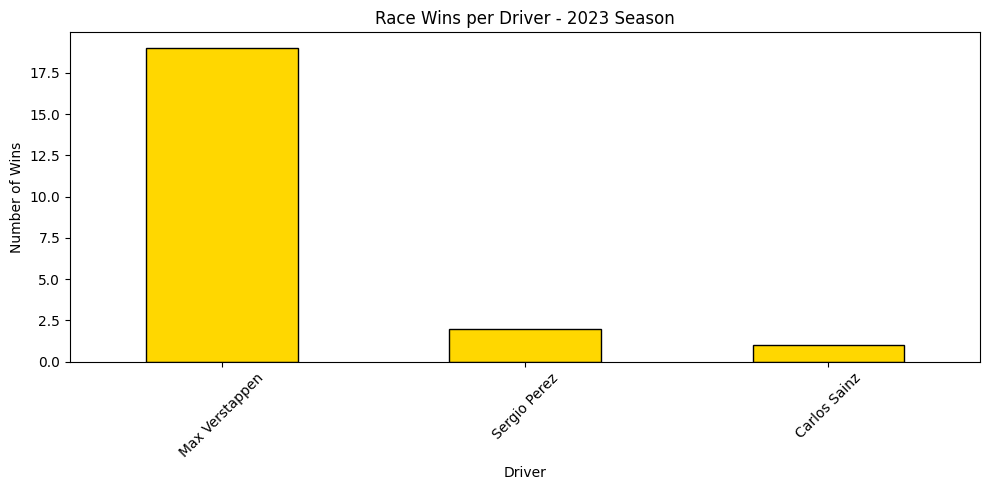

Chart saved!


In [9]:
os.makedirs('../charts', exist_ok=True)

plt.figure(figsize=(10, 5))
wins.plot(kind='bar', color='gold', edgecolor='black')
plt.title('Race Wins per Driver - 2023 Season')
plt.xlabel('Driver')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../charts/wins_per_driver.png', dpi=150)
plt.show()
print("Chart saved!")

In [10]:
team_points = df.groupby('TeamName')['Points'].sum().sort_values(ascending=False)
print("Total points per team:")
print(team_points)

Total points per team:
TeamName
Red Bull Racing    790.0
Mercedes           374.0
Ferrari            363.0
Aston Martin       266.0
McLaren            266.0
Alpine             110.0
Williams            26.0
AlphaTauri          22.0
Alfa Romeo          16.0
Haas F1 Team         9.0
Name: Points, dtype: float64


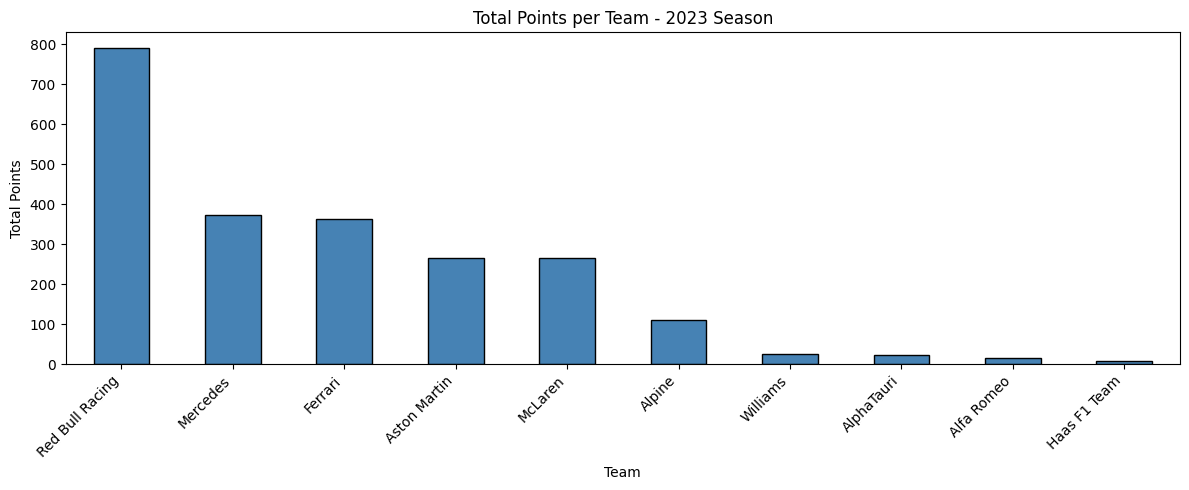

Chart saved!


In [11]:
plt.figure(figsize=(12, 5))
team_points.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Points per Team - 2023 Season')
plt.xlabel('Team')
plt.ylabel('Total Points')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../charts/points_per_team.png', dpi=150)
plt.show()
print("Chart saved!")

In [12]:
df_clean = df.dropna(subset=['GridPosition', 'Position'])
corr = df_clean['GridPosition'].corr(df_clean['Position'])
print(f"Correlation between GridPosition and Race Position: {corr:.3f}")
print("(Closer to 1.0 = stronger relationship)")

Correlation between GridPosition and Race Position: 0.566
(Closer to 1.0 = stronger relationship)


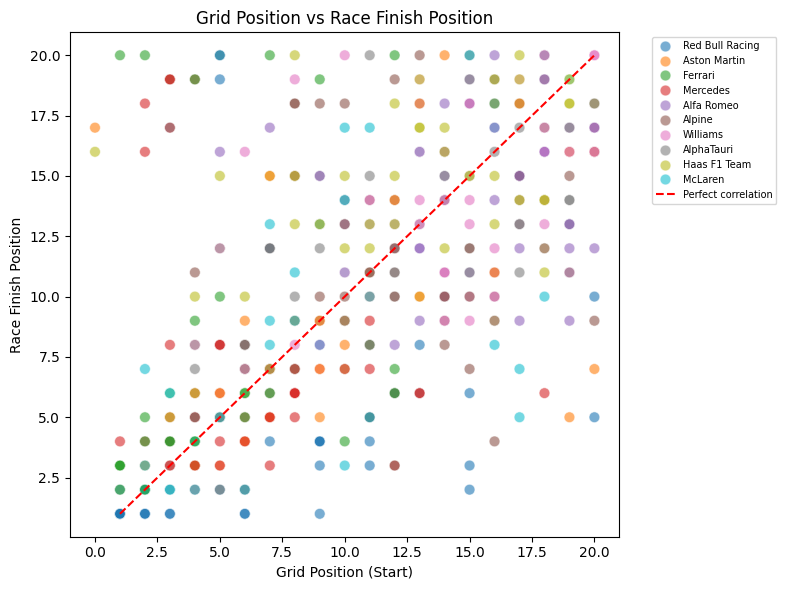

Chart saved!


In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean,
    x='GridPosition',
    y='Position',
    hue='TeamName',
    alpha=0.6,
    s=60
)
plt.plot([1, 20], [1, 20], 'r--', label='Perfect correlation')
plt.title('Grid Position vs Race Finish Position')
plt.xlabel('Grid Position (Start)')
plt.ylabel('Race Finish Position')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig('../charts/grid_vs_race.png', dpi=150)
plt.show()
print("Chart saved!")

In [14]:
df_clean = df_clean.copy()
df_clean['PositionChange'] = df_clean['GridPosition'] - df_clean['Position']
avg_change = df_clean.groupby('GridPosition')['PositionChange'].mean()
print("Average position change per grid slot:")
print(avg_change)

Average position change per grid slot:
GridPosition
0.0    -16.500000
1.0     -1.454545
2.0     -2.727273
3.0     -4.045455
4.0     -2.636364
5.0     -4.500000
6.0      0.090909
7.0     -2.090909
8.0     -2.863636
9.0     -0.272727
10.0    -1.227273
11.0     0.636364
12.0     0.954545
13.0    -0.409091
14.0     1.000000
15.0     2.181818
16.0     2.363636
17.0     2.681818
18.0     2.954545
19.0     4.727273
20.0     5.000000
Name: PositionChange, dtype: float64


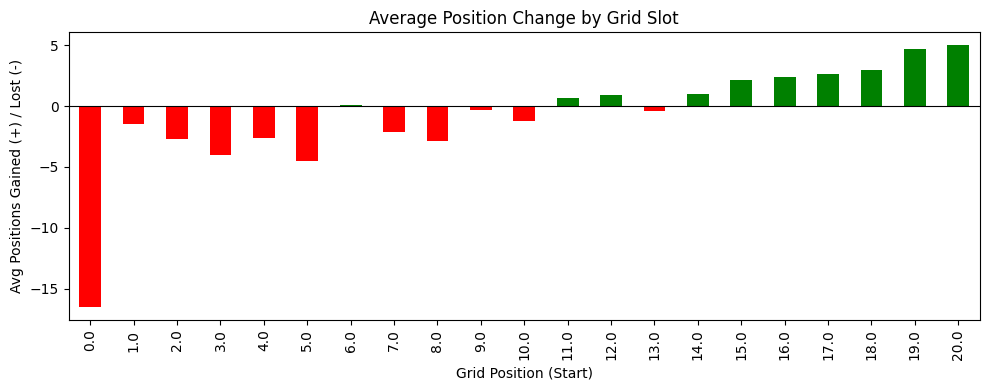

Chart saved!


In [15]:
plt.figure(figsize=(10, 4))
colors = ['green' if x > 0 else 'red' for x in avg_change]
avg_change.plot(kind='bar', color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Position Change by Grid Slot')
plt.xlabel('Grid Position (Start)')
plt.ylabel('Avg Positions Gained (+) / Lost (-)')
plt.tight_layout()
plt.savefig('../charts/position_change.png', dpi=150)
plt.show()
print("Chart saved!")

In [16]:
df['DNF'] = df['Status'].apply(
    lambda x: 0 if ('Finished' in str(x) or '+' in str(x)) else 1
)
dnf_by_team = df.groupby('TeamName')['DNF'].sum().sort_values(ascending=False)
print("DNFs per team:")
print(dnf_by_team)
print(f"\nTotal DNFs: {df['DNF'].sum()}")

DNFs per team:
TeamName
Haas F1 Team       27
Alfa Romeo         20
AlphaTauri         20
Williams           20
McLaren            12
Alpine             12
Ferrari             8
Aston Martin        8
Mercedes            6
Red Bull Racing     3
Name: DNF, dtype: int64

Total DNFs: 136


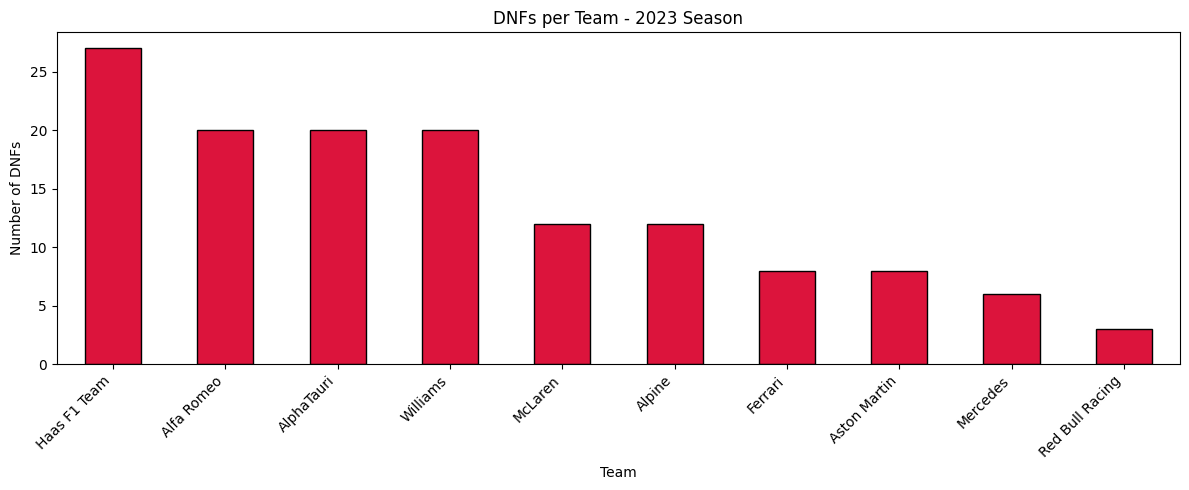

Chart saved!


In [17]:
plt.figure(figsize=(12, 5))
dnf_by_team.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('DNFs per Team - 2023 Season')
plt.xlabel('Team')
plt.ylabel('Number of DNFs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../charts/dnf_per_team.png', dpi=150)
plt.show()
print("Chart saved!")

In [18]:
print("Top3 distribution:")
print(df['Top3'].value_counts())
print(f"\n{df['Top3'].sum()} podium finishes out of {len(df)} total entries")

Top3 distribution:
Top3
0    374
1     66
Name: count, dtype: int64

66 podium finishes out of 440 total entries


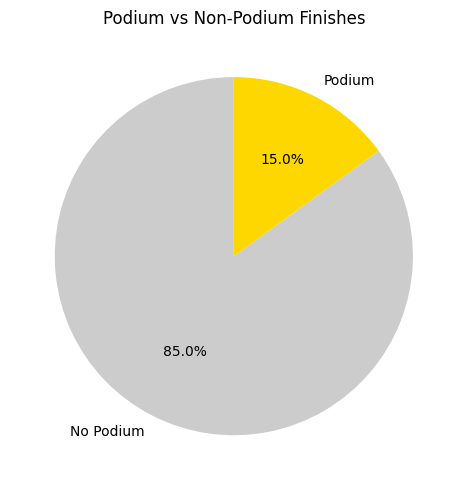

Chart saved!


In [19]:
plt.figure(figsize=(5, 5))
df['Top3'].value_counts().plot(
    kind='pie',
    labels=['No Podium', 'Podium'],
    colors=['#cccccc', 'gold'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Podium vs Non-Podium Finishes')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../charts/podium_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

In [20]:
print("Final DataFrame shape:", df.shape)
print("\nColumns ready for cleaning notebook:")
print(df.columns.tolist())
df.head(50)

Final DataFrame shape: (440, 14)

Columns ready for cleaning notebook:
['DriverNumber', 'BroadcastName', 'FullName', 'TeamName', 'Position', 'Points', 'Status', 'GridPosition', 'Time', 'Year', 'RaceName', 'Round', 'Top3', 'DNF']


,DriverNumber,BroadcastName,FullName,TeamName,Position,Points,Status,GridPosition,Time,Year,RaceName,Round,Top3,DNF
0,1,M VERSTAPPEN,Max Verstappen,Red Bull Racing,1.0,25.0,Finished,1.0,0 days 01:33:56.736000,2023,Bahrain,1,1,0
1,11,S PEREZ,Sergio Perez,Red Bull Racing,2.0,18.0,Finished,2.0,0 days 00:00:11.987000,2023,Bahrain,1,1,0
2,14,F ALONSO,Fernando Alonso,Aston Martin,3.0,15.0,Finished,5.0,0 days 00:00:38.637000,2023,Bahrain,1,1,0
3,55,C SAINZ,Carlos Sainz,Ferrari,4.0,12.0,Finished,4.0,0 days 00:00:48.052000,2023,Bahrain,1,0,0
4,44,L HAMILTON,Lewis Hamilton,Mercedes,5.0,10.0,Finished,7.0,0 days 00:00:50.977000,2023,Bahrain,1,0,0
5,18,L STROLL,Lance Stroll,Aston Martin,6.0,8.0,Finished,8.0,0 days 00:00:54.502000,2023,Bahrain,1,0,0
6,63,G RUSSELL,George Russell,Mercedes,7.0,6.0,Finished,6.0,0 days 00:00:55.873000,2023,Bahrain,1,0,0
7,77,V BOTTAS,Valtteri Bottas,Alfa Romeo,8.0,4.0,Finished,12.0,0 days 00:01:12.647000,2023,Bahrain,1,0,0
8,10,P GASLY,Pierre Gasly,Alpine,9.0,2.0,Finished,20.0,0 days 00:01:13.753000,2023,Bahrain,1,0,0
9,23,A ALBON,Alexander Albon,Williams,10.0,1.0,Finished,15.0,0 days 00:01:29.774000,2023,Bahrain,1,0,0


## EDA Summary
- Loaded 440 rows of raw F1 2023 race data
- Grid position is strongly correlated with race finish position
- Red Bull dominated with most wins and points
- DNFs tracked per team — reliability is a useful ML feature
- Created Top3 target variable (1 = Podium, 0 = Did not podium)
- Key ML features identified: GridPosition, TeamName, Points, DNF
- Next step: 03_clean_data.ipynb